# 1.1 EDA

In [1]:
#load data
import pandas as pd

train = pd.read_csv('car_crash_train.csv')
test = pd.read_csv('car_crash_test.csv')

In [2]:
#train
train.head()
train.info()
train.describe(include='all')
#Missing Values
train.isnull().sum()
#Target Distribution
train['Severity'].value_counts()
train['Severity'].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Crash Speed (km/h)         4000 non-null   int64  
 1   Impact Angle (degrees)     4000 non-null   int64  
 2   Airbag Deployed            4000 non-null   object 
 3   Seatbelt Used              4000 non-null   object 
 4   Weather Conditions         4000 non-null   object 
 5   Road Conditions            4000 non-null   object 
 6   Crash Type                 4000 non-null   object 
 7   Vehicle Type               4000 non-null   object 
 8   Vehicle Age (years)        4000 non-null   int64  
 9   Brake Condition            4000 non-null   object 
 10  Tire Condition             4000 non-null   object 
 11  Driver Age                 4000 non-null   int64  
 12  Driver Experience (years)  4000 non-null   int64  
 13  Alcohol Level (BAC%)       4000 non-null   float

,proportion
Severity,
Minor Injury,0.6890
Severe Injury,0.2595
Fatal,0.0515


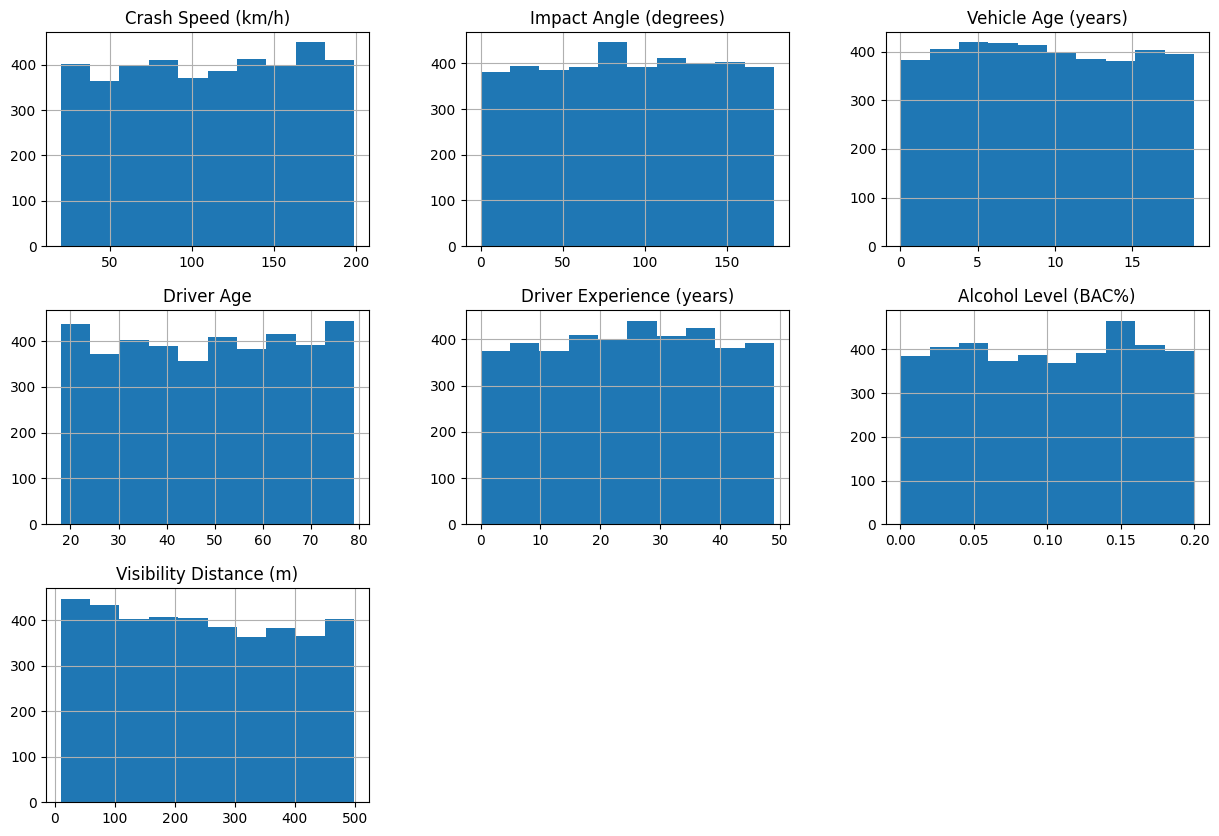

In [3]:
#Numerical Features Distribution
import matplotlib.pyplot as plt

num_cols = train.select_dtypes(include=['int64', 'float64']).columns

train[num_cols].hist(figsize=(15,10))
plt.show()

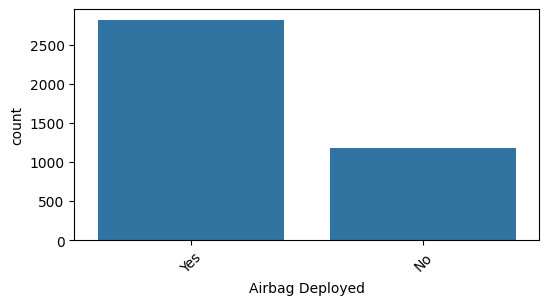

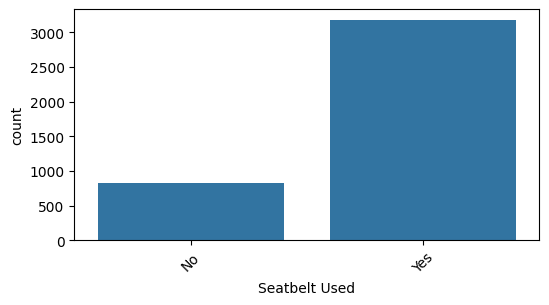

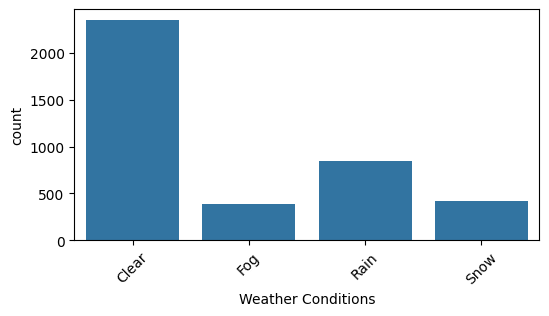

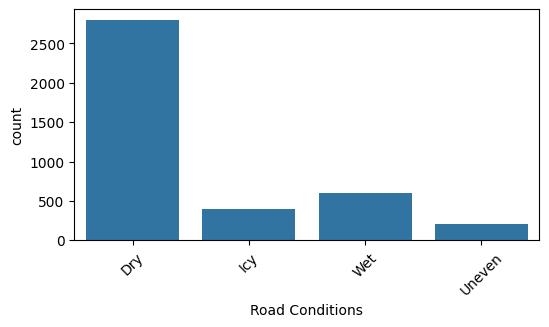

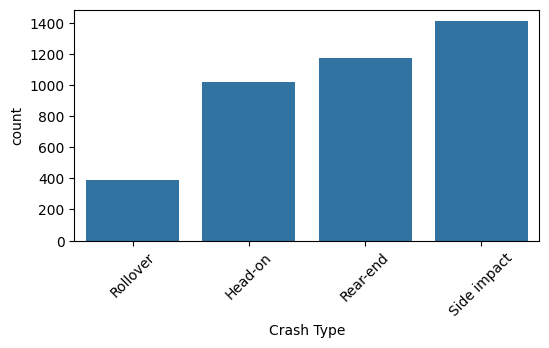

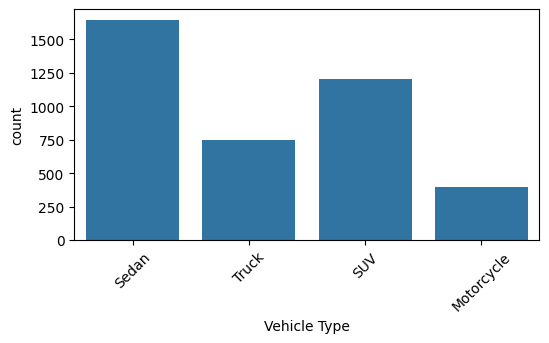

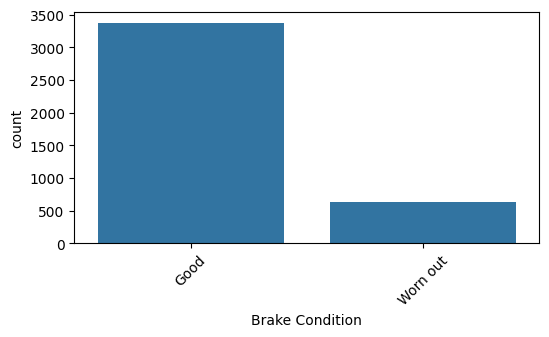

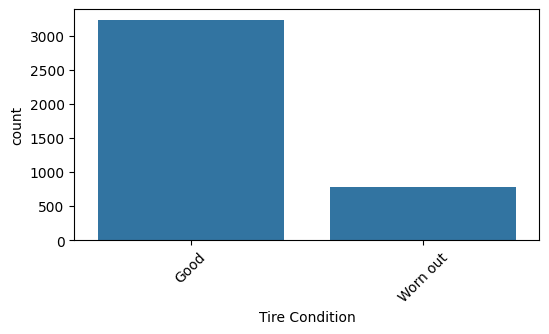

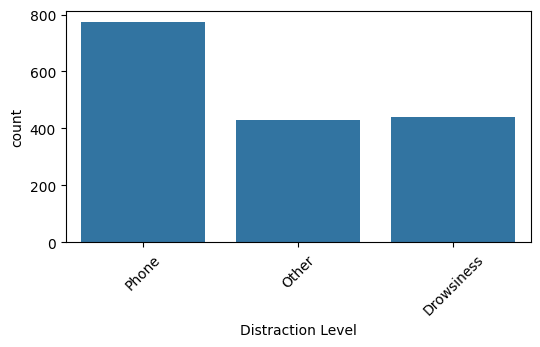

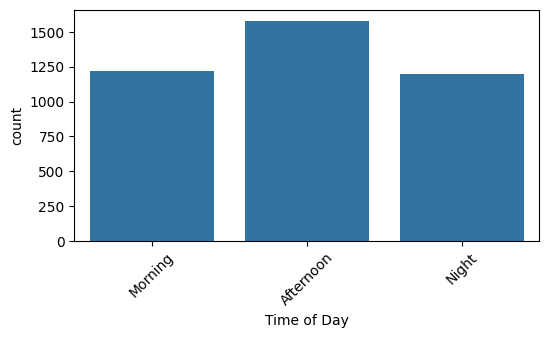

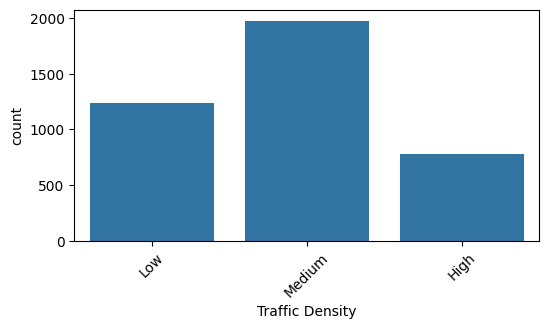

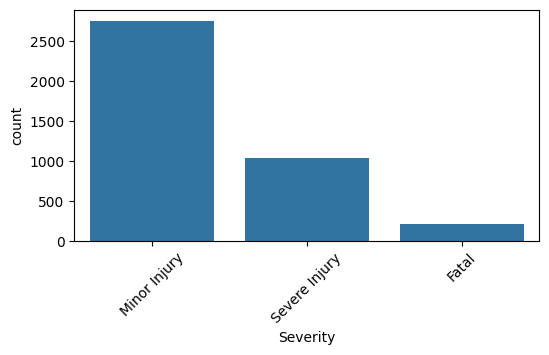

In [4]:
#Categorical Features Distribution
import seaborn as sns

cat_cols = train.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(x=col, data=train)
    plt.xticks(rotation=45)
    plt.show()

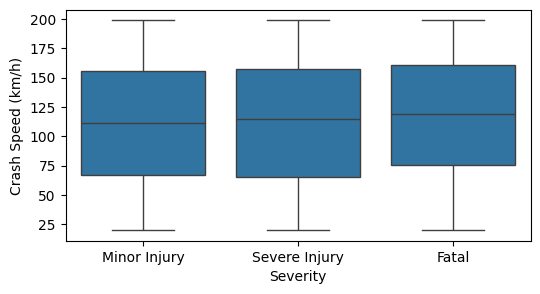

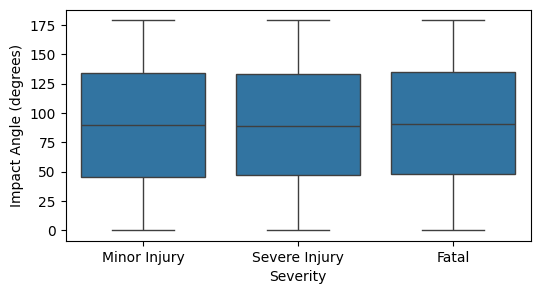

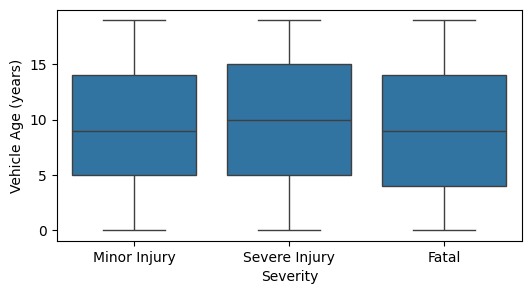

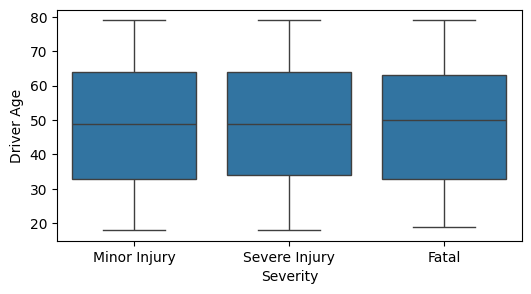

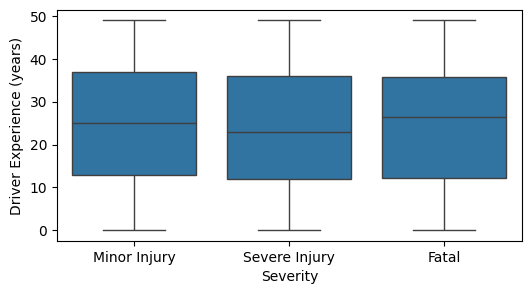

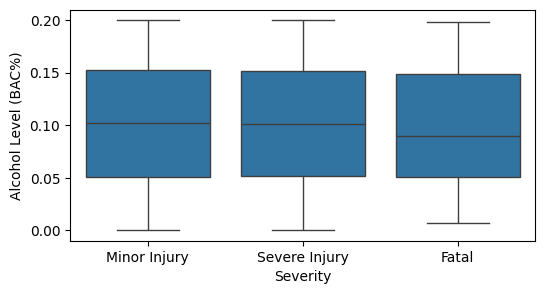

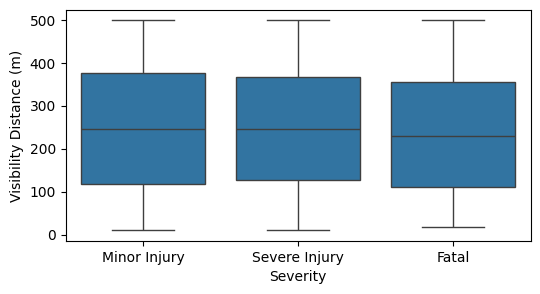

Severity            Fatal  Minor Injury  Severe Injury
Airbag Deployed                                       
No               0.053254      0.690617       0.256128
Yes              0.050763      0.688321       0.260916
Severity          Fatal  Minor Injury  Severe Injury
Seatbelt Used                                       
No             0.053269      0.677966       0.268765
Yes            0.051040      0.691871       0.257089
Severity               Fatal  Minor Injury  Severe Injury
Weather Conditions                                       
Clear               0.052878      0.689979       0.257143
Fog                 0.048969      0.698454       0.252577
Rain                0.046099      0.684397       0.269504
Snow                0.057007      0.684086       0.258907
Severity            Fatal  Minor Injury  Severe Injury
Road Conditions                                       
Dry              0.051576      0.694126       0.254298
Icy              0.048101      0.645570       0.306329


In [5]:
#Numerical vs Target
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x='Severity', y=col, data=train)
    plt.show()

#Categorical vs Target
for col in cat_cols:
    print(pd.crosstab(train[col], train['Severity'], normalize='index'))

# 1.2 Preprocessing

In [6]:
#PREPROCESSING
#Handle Missing Values
train['Distraction Level'] = train['Distraction Level'].fillna('Unknown')
test['Distraction Level'] = test['Distraction Level'].fillna('Unknown')


In [7]:
#Separate Target
X = train.drop('Severity', axis=1)
y = train['Severity']

In [8]:
#Encode Target
from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()
y = le_target.fit_transform(y)

In [9]:
#Encode Categorical Features (One-Hot)
X = pd.get_dummies(X, drop_first=True)
test = pd.get_dummies(test, drop_first=True)

# Align columns
X, test = X.align(test, join='left', axis=1, fill_value=0)

In [10]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['Crash Speed (km/h)', 'Impact Angle (degrees)',
            'Vehicle Age (years)', 'Driver Age',
            'Driver Experience (years)', 'Alcohol Level (BAC%)',
            'Visibility Distance (m)']

X[num_cols] = scaler.fit_transform(X[num_cols])
test[num_cols] = scaler.transform(test[num_cols])

In [11]:
#Handle Class Imbalance
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X, y = smote.fit_resample(X, y)

In [124]:
#Feature Engineering

#High speed + high alcohol → very high risk
#Low speed or low alcohol → lower risk
X['Risk Score'] = X['Crash Speed (km/h)'] * X['Alcohol Level (BAC%)']

#High value → very experienced for their age
#Low value → less experienced
X['Experience Ratio'] = X['Driver Experience (years)'] / (X['Driver Age'] + 1)

In [69]:
from sklearn.model_selection import train_test_split

# First split off test set
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Then split train/val from the remainder
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)
# Result: 60% train, 20% val, 20% test — same for ALL models

# 2.1 KNN

In [70]:
#Find Best K (Hyperparameter Tuning)
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

k_values = range(3, 21)
f1_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_val)
    f1 = f1_score(y_val, y_pred, average='weighted')
    f1_scores.append(f1)

best_k = k_values[np.argmax(f1_scores)]
print("Best K:", best_k)

Best K: 3


In [71]:
#Train Final Model
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [72]:
#Evaluate Model Performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_pred = knn.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, average='weighted')
recall = recall_score(y_val, y_pred, average='weighted')
f1 = f1_score(y_val, y_pred, average='weighted')

print("===== KNN PERFORMANCE =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nDetailed Report:\n")
print(classification_report(y_val, y_pred))

===== KNN PERFORMANCE =====
Accuracy  : 0.7249
Precision : 0.7230
Recall    : 0.7249
F1 Score  : 0.7106

Detailed Report:

              precision    recall  f1-score   support

           0       0.75      0.98      0.85       552
           1       0.73      0.48      0.58       551
           2       0.69      0.72      0.70       551

    accuracy                           0.72      1654
   macro avg       0.72      0.72      0.71      1654
weighted avg       0.72      0.72      0.71      1654



In [73]:
#Cross-Validation
#It performs 5-fold cross-validation Splits your dataset into 5 parts (folds) Repeats training/testing 5 times
from sklearn.model_selection import cross_val_score

knn = KNeighborsClassifier(n_neighbors=best_k)

cv_f1 = cross_val_score(knn, X, y, cv=5, scoring='f1_weighted')

print("===== CROSS-VALIDATION =====")
print("F1 Scores:", cv_f1)
print("Average F1:", cv_f1.mean())

===== CROSS-VALIDATION =====
F1 Scores: [0.71149137 0.72416365 0.76610623 0.74416478 0.75717329]
Average F1: 0.7406198637140207


The performance of the model was primarily evaluated using the weighted F1-score, as it provides a balanced measure of precision and recall, especially in the presence of class imbalance.With a F1 score equal to 0.79640282

2.1 KNN —
K was tuned by testing values from 3 to 20, evaluating each using weighted F1-score on the validation set. The best K was selected using np.argmax(f1_scores). No other parameters were tuned.
Results:

Validation Accuracy: 73.35%

Test Accuracy: 76.71%

Cross-validation Average F1: 0.7964


KNN is a distance-based algorithm, so it benefits from the StandardScaler applied earlier. However, it struggles with high-dimensional data (32 features after one-hot encoding) a problem known as the curse of dimensionality, where distances between points become less meaningful as dimensions increase.


# 2.2 Decision Trees

In [125]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)

In [126]:
#train the model
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [127]:
y_pred = dt.predict(X_val)

In [128]:
#Evaluate the Model
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_val, y_pred))

Accuracy: 0.6717741935483871


In [129]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_val, y_pred))
#Rows = actual class
#Columns = predicted class

[[340  25  37]
 [ 47 241 137]
 [ 53 108 252]]


In [130]:
#Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.85      0.81       402
           1       0.64      0.57      0.60       425
           2       0.59      0.61      0.60       413

    accuracy                           0.67      1240
   macro avg       0.67      0.67      0.67      1240
weighted avg       0.67      0.67      0.67      1240



In [131]:
#Check Overfitting
print("Train Accuracy:", dt.score(X_train, y_train))
print("Validation Accuracy:", dt.score(X_val, y_val))

Train Accuracy: 1.0
Validation Accuracy: 0.6717741935483871


In [132]:
#Improve the Model
dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [133]:
#Check Overfitting
print("Train Accuracy:", dt.score(X_train, y_train))
print("Validation Accuracy:", dt.score(X_val, y_val))

Train Accuracy: 0.6792811473993433
Validation Accuracy: 0.5338709677419354


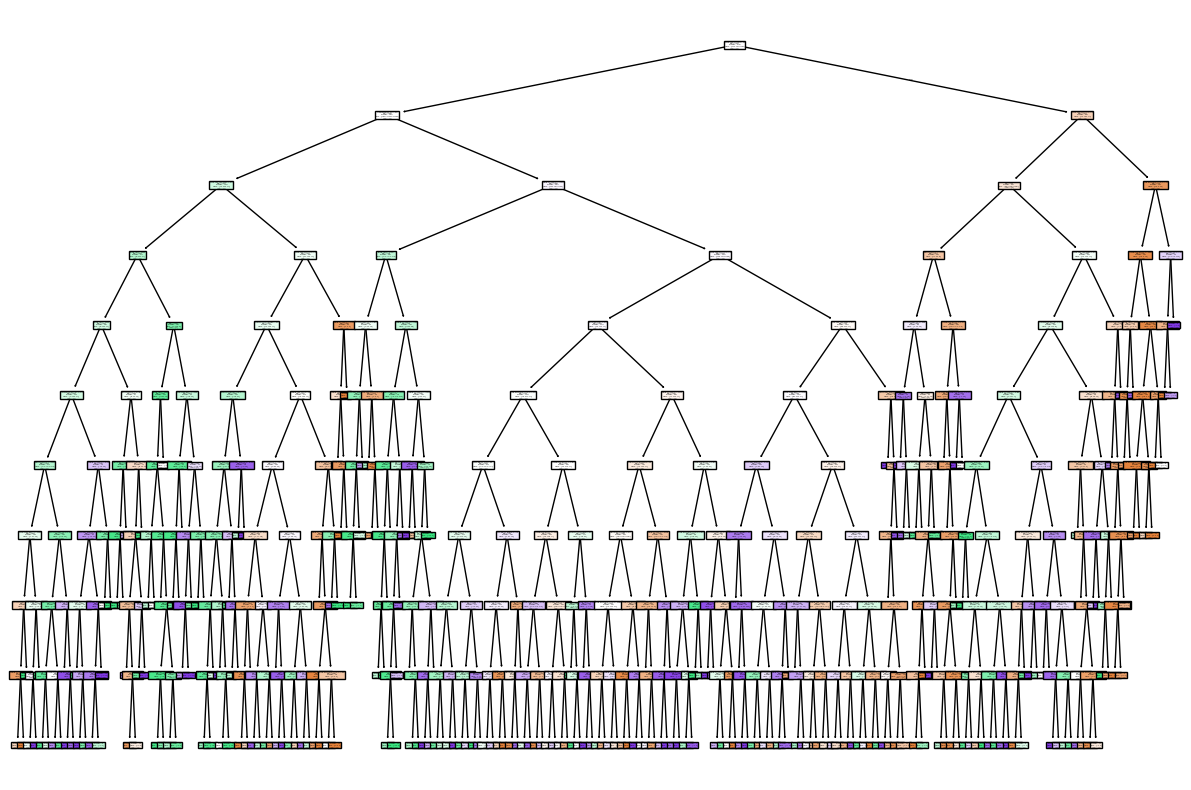

In [134]:
#Visualize the Tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plot_tree(dt, filled=True, feature_names=X.columns, class_names=True)
plt.show()

In [135]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

params = {
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                    params, cv=5)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV score: 0.6357389054833311


In [85]:
train_acc_dt = dt.score(X_train, y_train)
val_acc_dt = dt.score(X_val, y_val)
print(train_acc_dt)
print(val_acc_dt)

0.7165322580645161
0.5616686819830713


2.2 Decision Tree
Started with a default unpruned tree (which overfit), then manually set max_depth=10, min_samples_split=10, min_samples_leaf=5.

GridSearchCV was then used with:

max_depth: [5, 10, 15, None]
min_samples_split: [2, 5, 10]
min_samples_leaf: [1, 2, 5]

Results:

Validation Accuracy: 53.39%
Test Accuracy: 55.36%

The default unpruned tree overfit heavily (train accuracy near 100%, validation much lower). Even after pruning via GridSearchCV, the Decision Tree struggled because a single tree is prone to high variance small changes in data can lead to very different splits. It also cannot capture the combined patterns that an ensemble can, making it the weakest tree-based model here.

# 2.3 Random Forest

In [167]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)

In [168]:
#Evaluate the Model
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_val, y_pred))

Accuracy: 0.8459677419354839


In [169]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_val, y_pred))

[[392   9   1]
 [ 11 344  70]
 [  8  92 313]]


In [170]:
#Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       402
           1       0.77      0.81      0.79       425
           2       0.82      0.76      0.79       413

    accuracy                           0.85      1240
   macro avg       0.85      0.85      0.85      1240
weighted avg       0.85      0.85      0.85      1240



In [171]:
#Check Overfitting
print("Train Accuracy:", rf.score(X_train, y_train))
print("Validation Accuracy:", rf.score(X_val, y_val))

Train Accuracy: 1.0
Validation Accuracy: 0.8459677419354839


<Axes: >

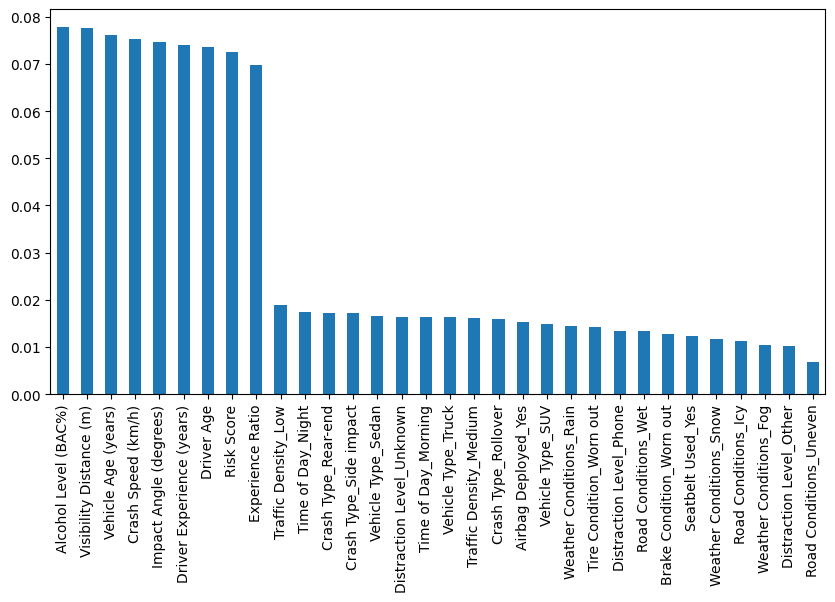

In [172]:
#Feature Importance
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))

In [173]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [176]:
# Use the best estimator from grid search
best_rf = grid.best_estimator_

print("Best Params:", grid.best_params_)
print("Train Accuracy:", best_rf.score(X_train, y_train))
print("Validation Accuracy:", best_rf.score(X_val, y_val))

Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Train Accuracy: 1.0
Validation Accuracy: 0.8572580645161291


2.3 Random Forest
Started with default parameters, then tuned via GridSearchCV with:

n_estimators: [100, 200]
max_depth: [5, 10, None]
min_samples_split: [2, 5, 10]
min_samples_leaf: [1, 2, 5]

The best estimator was saved as best_rf = grid.best_estimator_. Feature importance was also plotted to understand which features drove predictions.
Results:

Validation Accuracy: 85.73%

Test Accuracy: 88.40%

Test Accuracy after retraining on full data: 89.52%

Random Forest is an ensemble of many decision trees, each trained on a random subset of data and features. This reduces variance significantly compared to a single Decision Tree. It naturally handles non-linear relationships, feature interactions, and is robust to outliers. The engineered features (Risk Score, Experience Ratio) and SMOTE balancing also contributed positively.

# 2.4 Logistic Regression

In [177]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_X_train = scaler.fit_transform(X_train)
scaled_X_val = scaler.transform(X_val)
scaled_X_test = scaler.transform(X_test)

In [178]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(scaled_X_train, y_train)

LogisticRegression(max_iter=1000)

In [179]:
y_pred = log_model.predict(scaled_X_test)

In [180]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.5318291700241741

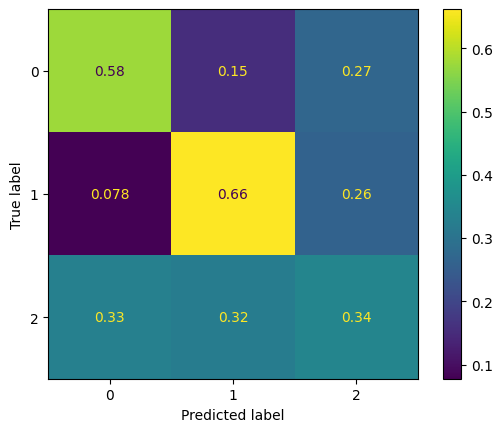

In [181]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize='true'
)

In [182]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      0.58      0.59       441
           1       0.58      0.66      0.62       411
           2       0.37      0.34      0.36       389

    accuracy                           0.53      1241
   macro avg       0.52      0.53      0.52      1241
weighted avg       0.53      0.53      0.53      1241



In [183]:
val_pred = log_model.predict(scaled_X_val)

from sklearn.metrics import accuracy_score
print("Validation Accuracy:", accuracy_score(y_val, val_pred))

Validation Accuracy: 0.5233870967741936


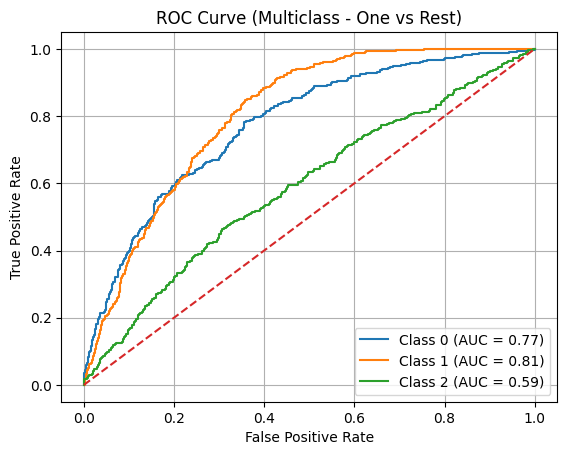

Overall AUC (OvR): 0.7231025793449808


In [184]:
# ROC Curve for Multiclass (One-vs-Rest)

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# 1. Get predicted probabilities
y_prob = log_model.predict_proba(scaled_X_test)

# 2. Binarize the labels (for multiclass ROC)
classes = log_model.classes_
y_test_bin = label_binarize(y_test, classes=classes)

# 3. Compute ROC curve for each class
fpr = dict()
tpr = dict()
auc_scores = dict()

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    auc_scores[i] = roc_auc_score(y_test_bin[:, i], y_prob[:, i])

# 4. Plot all ROC curves
plt.figure()

for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label=f"Class {classes[i]} (AUC = {auc_scores[i]:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multiclass - One vs Rest)")
plt.legend()
plt.grid()
plt.show()

# 5. Overall AUC score
overall_auc = roc_auc_score(y_test, y_prob, multi_class="ovr")
print("Overall AUC (OvR):", overall_auc)

2.4 Logistic Regression

No hyperparameter tuning was performed. Used default settings with max_iter=1000 (increased from default 100 to ensure convergence). Features were re-scaled using a separate StandardScaler before training.
Results:

Validation Accuracy: 52.34%

Test Accuracy: 53.18%


Logistic Regression assumes a linear decision boundary between classes. Car crash severity is determined by complex, non-linear interactions between features ( high speed + high alcohol + low visibility together cause severe crashes, not each independently). Since the relationship is inherently non-linear, Logistic Regression cannot capture it well, resulting in the lowest accuracy among the models.

# 2.5 Naive Bayes

Gaussian Naive Bayes → used because  data has continuous numeric features (best fit )
Multinomial Naive Bayes → for counts (like word frequencies)  not this case
Bernoulli Naive Bayes → for binary (0/1) features only

In [185]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [186]:
y_pred = model.predict(X_test)

In [187]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      0.32      0.42       441
           1       0.57      0.49      0.53       411
           2       0.35      0.60      0.44       389

    accuracy                           0.46      1241
   macro avg       0.51      0.47      0.46      1241
weighted avg       0.52      0.46      0.46      1241



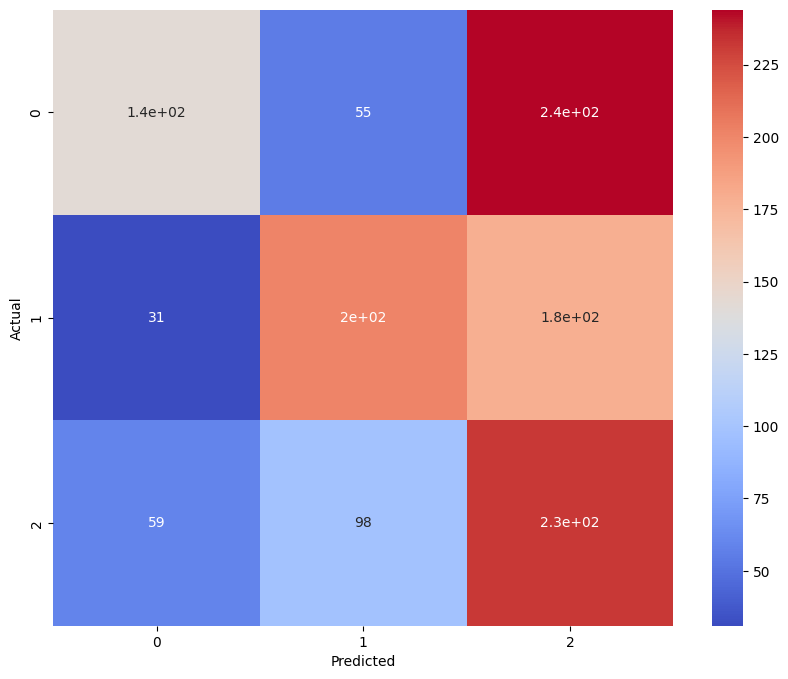

In [188]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, cmap='coolwarm')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [189]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.46333601933924257


In [190]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [191]:
from sklearn.metrics import accuracy_score

val_pred = model.predict(X_val)
val_acc = accuracy_score(y_val, val_pred)

print("Validation Accuracy:", val_acc)

Validation Accuracy: 0.4782258064516129


In [192]:
test_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

print("Test Accuracy:", test_acc)

Test Accuracy: 0.46333601933924257


2.5 Naive Bayes — Gaussian NB

Gaussian NB was chosen (over Multinomial or Bernoulli) because the features are continuous numerical values, which Gaussian NB models by assuming each feature follows a normal distribution.

Results:

Validation Accuracy: 47.82%

Test Accuracy: 46.33%


Naive Bayes makes two strong assumptions that are violated in this dataset:
(1) feature independence — in reality, speed, alcohol level, visibility, and driver experience are all correlated with each other; and
(2) Gaussian distribution — the features may not perfectly follow a normal distribution even after scaling.
These violated assumptions explain why it performed the worst overall, even below random chance level for some classes (as seen in the confusion matrix where class 2 was heavily over-predicted).

# 3 Conclusion

In [193]:
# ========== VALIDATION ACCURACY COMPARISON ==========
from sklearn.metrics import accuracy_score
import pandas as pd

results = {}

# KNN - refit with best_k
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
results['KNN'] = accuracy_score(y_val, knn.predict(X_val))

# Decision Tree
results['Decision Tree'] = accuracy_score(y_val, dt.predict(X_val))

# Random Forest
results['Random Forest'] = accuracy_score(y_val, best_rf.predict(X_val))

# Logistic Regression (uses scaled_X_val)
results['Logistic Regression'] = accuracy_score(y_val, log_model.predict(scaled_X_val))

# Naive Bayes (uses its own X_val from its split)
results['Naive Bayes'] = accuracy_score(y_val, model.predict(X_val))

# Display
df_results = pd.DataFrame(results.items(), columns=['Model', 'Validation Accuracy'])
df_results = df_results.sort_values('Validation Accuracy', ascending=False).reset_index(drop=True)
df_results['Validation Accuracy'] = df_results['Validation Accuracy'].map('{:.4f}'.format)

print("=" * 40)
print("   MODEL VALIDATION ACCURACY COMPARISON")
print("=" * 40)
print(df_results.to_string(index=False))
print("=" * 40)

   MODEL VALIDATION ACCURACY COMPARISON
              Model Validation Accuracy
      Random Forest              0.8573
                KNN              0.7435
      Decision Tree              0.5339
Logistic Regression              0.5234
        Naive Bayes              0.4782


In [194]:
from sklearn.metrics import accuracy_score
import pandas as pd

# Refit KNN
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

results = {}
for name, mdl, X_t in [
    ('KNN',                 knn,       X_test),
    ('Decision Tree',       dt,        X_test),
    ('Random Forest',       best_rf,   X_test),
    ('Logistic Regression', log_model, scaled_X_test),
    ('Naive Bayes',         model,     X_test),
]:
    results[name] = accuracy_score(y_test, mdl.predict(X_t))

df_results = pd.DataFrame(results.items(), columns=['Model', 'Test Accuracy'])
df_results = df_results.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
df_results['Test Accuracy'] = df_results['Test Accuracy'].map('{:.4f}'.format)

print("=" * 40)
print("     MODEL TEST ACCURACY COMPARISON")
print("=" * 40)
print(df_results.to_string(index=False))
print("=" * 40)

     MODEL TEST ACCURACY COMPARISON
              Model Test Accuracy
      Random Forest        0.8840
                KNN        0.7671
      Decision Tree        0.5536
Logistic Regression        0.5318
        Naive Bayes        0.4633


Among all five models evaluated, Random Forest achieved the highest performance with a validation accuracy of 85.73% and a test accuracy of 88.40%, making it the best-performing model for predicting car crash severity. KNN followed in second place with 73.35% validation and 76.71% test accuracy, showing reasonable generalization. Decision Tree performed moderately with 53.39% validation and 55.36% test accuracy, while Logistic Regression and Naive Bayes were the weakest models, achieving 52.34% and 47.82% validation accuracy respectively.
The low performance of Logistic Regression suggests that the relationship between the features and crash severity is non-linear, which Logistic Regression cannot capture effectively. Naive Bayes struggled due to its strong assumption of feature independence, which is unlikely to hold in a real-world dataset where features such as speed, alcohol level, and driver experience are naturally correlated.
The consistency between validation and test accuracy across all models confirms that they generalized well to unseen data without significant overfitting. Random Forest's superior performance is attributed to its ensemble approach of combining multiple decision trees, which reduces variance and captures complex non-linear patterns in the data, making it the most suitable model for this classification task.

In [195]:
# Combine train + val back into full labeled data
import numpy as np

X_full = np.concatenate([X_train, X_val], axis=0)
y_full = np.concatenate([y_train, y_val], axis=0)

# Retrain best model (Random Forest) on full data
best_rf.fit(X_full, y_full)

print("Model retrained on full dataset.")
print("Full dataset size:", X_full.shape)

Model retrained on full dataset.
Full dataset size: (7027, 32)


In [197]:
X_test_array = X_test.values  # convert to numpy
test_pred = best_rf.predict(X_test_array)
test_acc = accuracy_score(y_test, test_pred)
print(f"Test Accuracy (after retraining on full data): {test_acc:.4f}")

Test Accuracy (after retraining on full data): 0.8952
